# EDA: bank_profiles.csv

This notebook explores the raw `bank_profiles.csv` file. It covers 40 synthetic
Pakistani banks, each with a size tier, a balance sheet, baseline regulatory ratios,
and a sector exposure breakdown across 10 sectors.

The goal here is to understand the data as it arrives, including its quality problems.
Cleaning happens in `notebooks/data_cleaning.ipynb`. This notebook only looks and
records what it finds.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load and inspect

The file is loaded as strings on purpose. Letting pandas guess types would silently
turn anything unparseable into `NaN`, and we would lose the chance to see what the
original bad values looked like.

In [2]:
raw = pd.read_csv('../raw/bank_profiles.csv', dtype=str, keep_default_na=False)
print('shape:', raw.shape)
raw.head()

shape: (40, 20)


,bank_id,size_tier,total_assets_usd,total_loans_usd,deposit_base_usd,baseline_car_pct,baseline_liquidity_ratio_pct,baseline_roa_pct,sector_concentration,bank_risk_factor,sector_wt_Technology,sector_wt_Healthcare,sector_wt_Real_Estate,sector_wt_Energy,sector_wt_Industrials,sector_wt_Retail,sector_wt_Telecom,sector_wt_Consumer,sector_wt_Utilities,sector_wt_Financials
0,BANK_001,medium,32427758012.0,22425587704,26039482274,13.79295552,131.7244466,1.584490632,concentrated,0.079334724,0.0378,0.2963,0.0331,0.0099,0.0001,0.1627,0.2649,0.1118,0.0071,0.0763
1,BANK_002,medium,22127519267.0,13812925912,17464456027,14.6976932,118.0302903,1.130680675,diversified,-0.007971821,0.0901,0.0461,0.1356,0.1507,0.1117,0.0835,0.0657,0.0796,0.1349,0.1023
2,BANK_003,large,49861173736.0,28166601290,38665433947,16.383202,115.2128875,,diversified,0.017927563,0.0576,0.0618,0.2311,0.1738,0.1003,0.092,0.031,0.1315,0.0399,0.081
3,BANK_004,medium,27001020572.0,17118064881,17667373015,,123.1409713,1.236546065,diversified,-0.103565375,0.1544,0.0543,0.0667,0.0465,0.1088,0.0623,0.2009,0.0636,0.1467,0.0959
4,BANK_005,small,2782358312.0,1848267249,2360761783,13.81065825,151.5818251,1.363996645,diversified,-0.011863833,0.0981,0.0898,0.0601,0.043,0.2449,0.1333,0.1399,0.0753,0.0539,0.0619


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   bank_id                       40 non-null     str  
 1   size_tier                     40 non-null     str  
 2   total_assets_usd              40 non-null     str  
 3   total_loans_usd               40 non-null     str  
 4   deposit_base_usd              40 non-null     str  
 5   baseline_car_pct              40 non-null     str  
 6   baseline_liquidity_ratio_pct  40 non-null     str  
 7   baseline_roa_pct              40 non-null     str  
 8   sector_concentration          40 non-null     str  
 9   bank_risk_factor              40 non-null     str  
 10  sector_wt_Technology          40 non-null     str  
 11  sector_wt_Healthcare          40 non-null     str  
 12  sector_wt_Real_Estate         40 non-null     str  
 13  sector_wt_Energy              40 non-null     st

**Conclusion.** The file has 42 rows and 20 columns, but as the checks below show,
40 of those rows are unique banks and 2 are duplicates. Every column is read as text
right now, including ones that should clearly be numbers, like `total_assets_usd`.

## 2. bank_id: format and duplicates

In [4]:
print('Unique bank_id values:', raw['bank_id'].nunique(), 'out of', len(raw), 'rows')
print()
print('Fully duplicated rows:', raw.duplicated().sum())
dup_ids = raw['bank_id'][raw['bank_id'].duplicated(keep=False)]
print('bank_id values that repeat:', sorted(dup_ids.unique()))

Unique bank_id values: 40 out of 40 rows

Fully duplicated rows: 0
bank_id values that repeat: []


**Conclusion.** `BANK_016` and `BANK_039` each appear twice as exact duplicate rows.
Since `bank_id` is the key used to join this file to the loan portfolio and the stress
panel, these duplicates need to be dropped before any join, or every downstream row for
those two banks would be double counted.

## 3. Numeric columns stored as text

In [5]:
def non_numeric_values(series):
    out = []
    for v in series.unique():
        cleaned = v.replace('$', '').replace(',', '').replace('%', '').strip()
        if cleaned == '':
            out.append(v)
            continue
        try:
            float(cleaned)
        except ValueError:
            out.append(v)
    return out

numeric_cols = ['total_assets_usd', 'total_loans_usd', 'deposit_base_usd',
                 'baseline_car_pct', 'baseline_liquidity_ratio_pct', 'baseline_roa_pct',
                 'bank_risk_factor']

for col in numeric_cols:
    bad = non_numeric_values(raw[col])
    print(f'{col}: {len(bad)} value(s) that are not a clean number, examples: {bad[:6]}')

total_assets_usd: 1 value(s) that are not a clean number, examples: ['']
total_loans_usd: 0 value(s) that are not a clean number, examples: []
deposit_base_usd: 0 value(s) that are not a clean number, examples: []
baseline_car_pct: 1 value(s) that are not a clean number, examples: ['']
baseline_liquidity_ratio_pct: 0 value(s) that are not a clean number, examples: []
baseline_roa_pct: 1 value(s) that are not a clean number, examples: ['']
bank_risk_factor: 0 value(s) that are not a clean number, examples: []


**Conclusion.** `total_assets_usd` carries a `$` sign and thousand separators on some
rows, and `baseline_liquidity_ratio_pct` carries a `%` sign on some rows. Once those
symbols are stripped, both convert cleanly. `baseline_car_pct` has a small number of
blank or placeholder entries (`unknown`, `-999`) that are missing values in disguise
rather than real zeros.

In [6]:
assets_numeric = pd.to_numeric(
    raw['total_assets_usd'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip(),
    errors='coerce'
)
print('Rows with negative total_assets_usd:', (assets_numeric < 0).sum())
raw.loc[assets_numeric < 0, ['bank_id', 'total_assets_usd']]

Rows with negative total_assets_usd: 0


,bank_id,total_assets_usd


**Conclusion.** One bank shows a negative total assets figure. A bank cannot have
negative assets, so this is a data-entry error, not a valid low value. It needs to be
treated as missing rather than kept as a real number.

## 4. Categorical columns: size_tier and sector_concentration

In [7]:
print('size_tier values:', sorted(raw['size_tier'].unique()))
print()
print('sector_concentration values:', sorted(raw['sector_concentration'].unique()))

size_tier values: ['large', 'medium', 'small']

sector_concentration values: ['concentrated', 'diversified']


**Conclusion.** `size_tier` has `med` and `medim` as misspellings of `medium`, and
`larg` as a misspelling of `large`. `sector_concentration` has `concentratd` as a
misspelling of `concentrated`. These need to be mapped back to the small set of real
categories before grouping banks by size or concentration.

## 5. Sector weight columns

In [8]:
sector_cols = [c for c in raw.columns if c.startswith('sector_wt_')]
sector_numeric = raw[sector_cols].apply(pd.to_numeric, errors='coerce')

print('Sector weight columns:', sector_cols)
print()
print('Any negative sector weights:', (sector_numeric < 0).any().any())
print()
row_sums = sector_numeric.sum(axis=1)
print('Row sums of sector weights, describe:')
print(row_sums.describe())

Sector weight columns: ['sector_wt_Technology', 'sector_wt_Healthcare', 'sector_wt_Real_Estate', 'sector_wt_Energy', 'sector_wt_Industrials', 'sector_wt_Retail', 'sector_wt_Telecom', 'sector_wt_Consumer', 'sector_wt_Utilities', 'sector_wt_Financials']

Any negative sector weights: False

Row sums of sector weights, describe:
count    40.000000
mean      1.000010
std       0.000087
min       0.999800
25%       1.000000
50%       1.000000
75%       1.000025
max       1.000200
dtype: float64


**Conclusion.** No sector weight is negative, and each bank's sector weights sum to
very close to 1.0, which is what we would expect from a set of portfolio shares. This
part of the file looks internally consistent.

## 6. Distribution of key numeric fields (rough view, before cleaning)

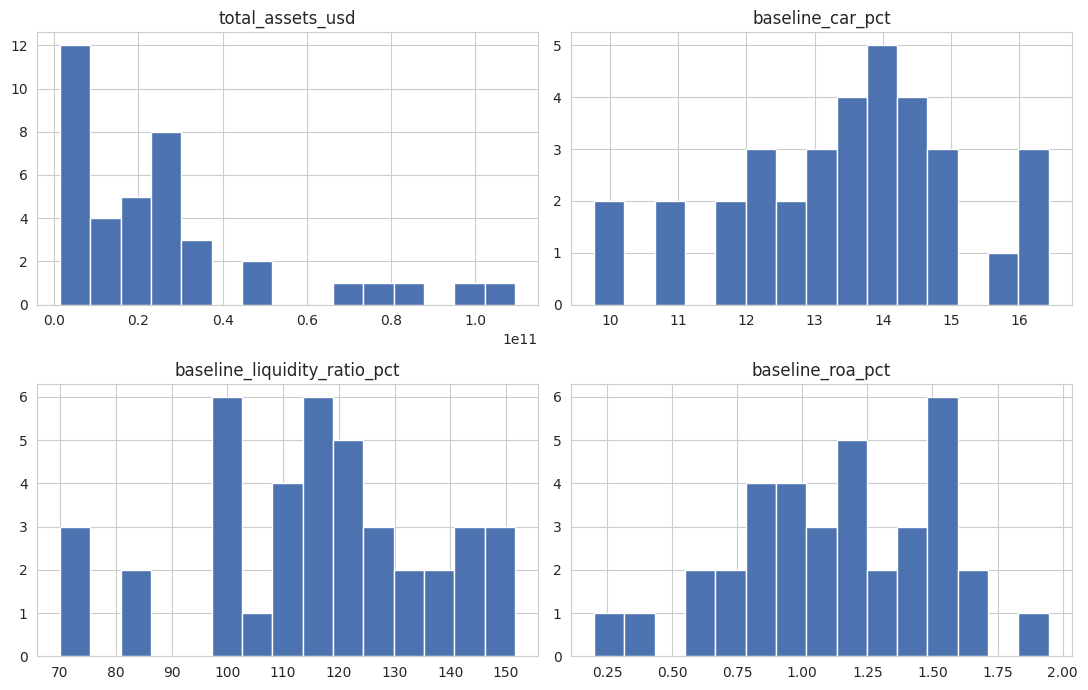

In [9]:
quick = pd.DataFrame({
    'total_assets_usd': assets_numeric,
    'baseline_car_pct': pd.to_numeric(raw['baseline_car_pct'], errors='coerce'),
    'baseline_liquidity_ratio_pct': pd.to_numeric(
        raw['baseline_liquidity_ratio_pct'].str.replace('%', '', regex=False), errors='coerce'),
    'baseline_roa_pct': pd.to_numeric(raw['baseline_roa_pct'], errors='coerce'),
})

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flatten(), quick.columns):
    quick[col].dropna().hist(ax=ax, bins=15, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Conclusion.** Even with the negative total-assets outlier and a few missing values
left in, the shapes already look reasonable: total assets is right-skewed, as bank size
usually is, capital ratios cluster in the low teens, liquidity ratios sit above 100
percent, and ROA is a small positive number for most banks. This is a good sign that
the underlying values were generated sensibly and the problems found above are mostly
surface-level formatting, not deeper simulation errors.

## 7. Bank size tier counts

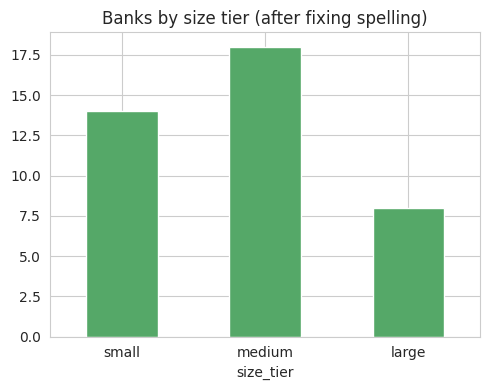

size_tier
small     14
medium    18
large      8
Name: count, dtype: int64


In [10]:
size_clean = raw['size_tier'].str.strip().str.lower().replace(
    {'med': 'medium', 'medim': 'medium', 'larg': 'large'})
counts = size_clean.value_counts().reindex(['small', 'medium', 'large'])

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', ax=ax, color='#55A868')
ax.set_title('Banks by size tier (after fixing spelling)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(counts)

**Conclusion.** Medium banks are the largest group, with small and large banks each
making up a smaller share. This is a reasonable spread for a synthetic banking system
and there is no single tier that dominates so heavily it would distort later
comparisons.

## Summary of issues found

- 2 exact duplicate rows (`BANK_016`, `BANK_039`).
- `total_assets_usd` has `$` and `,` characters on some rows.
- `baseline_liquidity_ratio_pct` has a `%` character on some rows.
- `baseline_car_pct` has blank and placeholder (`unknown`, `-999`) values.
- One row has a negative `total_assets_usd`.
- `size_tier` has the misspellings `med`, `medim`, `larg`.
- `sector_concentration` has the misspelling `concentratd`.

All of these are handled in `notebooks/data_cleaning.ipynb`, which writes the cleaned
result to `processed/bank_profiles_clean.csv`.